# Value-gradient propagation — poor vs good control

**The question.** Can the critic's gradient `∂V/∂p` (how the value changes if you nudge a leg's
presence) be the training signal for a future morphology *generator* — emit a body, push it uphill on
`V`? Presence is a continuous `p∈[0,1]` fed to the critic's length slots; its **sign** should say which
way a leg should move (**+** = should-be-on, **−** = should-be-off, regardless of current state — a
direction, not an importance score).

**What changed in this version.** Earlier the body was `Bernoulli(p)` and the policy couldn't observe
the body it controlled — a *poor* value function. Now the body is built **exactly = a clean stable
center**, and `p` is fed to obs/value **only** (a `√U` cloud around the center). The policy always
controls a real morph → much stronger control (seed-avg return 3992 vs 2545), and `V(p)` is the value
of the center `p` implies. This notebook reruns every probe on the **good control** and contrasts it
with the poor one.

**The short answer.** Sign + *shape* now both pass: `∂V/∂p` is positive almost everywhere (no myopia)
and — unlike before — **largest exactly at low `p`** (correct diminishing returns), it interpolates to
held-out bodies, and it survives a generator net (sign-align 0.95). Magnitude is still not a reliable
"which leg" signal, but the *reason* changed: the good `V` now encodes per-leg structure (its
finite-difference recovers it) yet the analytic gradient diverges from it. Loads every seed under
`data/value_grad_prop/*_nobern/grad.npz`. Full write-up: `docs/value_gradient_propagation.md`.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
runs = sorted((ROOT / 'data' / 'value_grad_prop').glob('*/grad.npz'))
D = {p.parent.name: np.load(p, allow_pickle=True) for p in runs}
print('seeds:', list(D))
EDGES = np.linspace(0.0, 1.0, 11)            # 10 p-bins for the dV/dp-vs-p headline
CEN = 0.5 * (EDGES[:-1] + EDGES[1:])

def per_leg(d):
    """Flatten (env,leg) -> p, g_mean, g0, and the env's sampled leg count broadcast per leg."""
    p, gm, g0, lc = d['p'], d['g_mean'], d['g0'], d['leg_count']
    lc8 = np.repeat(lc[:, None], 8, 1)
    return dict(p=p.ravel(), gm=gm.ravel(), g0=g0.ravel(), lc=lc8.ravel())
P = {s: per_leg(d) for s, d in D.items()}

def binned(p, g):
    """Mean of g within each p-bin (nan if empty)."""
    idx = np.clip(np.digitize(p, EDGES) - 1, 0, len(EDGES) - 2)
    return np.array([g[idx == b].mean() if (idx == b).any() else np.nan for b in range(len(CEN))])

seeds: ['s42_nobern', 's43_nobern', 's44_nobern']


## Premise sanity — reward vs center leg-count ("more legs better")

**Hypothesis.** Step-1 logic rests on "more legs → more reward," so raising any leg's `p` should help
and a useful gradient should point *up* everywhere. Confirm the premise first.

**How it works.** One line per seed: mean episode reward vs the body's **center** on-leg count (the
body is now built exactly at the center; count 5 is held out of training, so it's absent).

**What we found.** Clean monotonic climb across all seeds — ~1200 reward at 3 legs up to ~8200 at 8
legs (far higher than the previous Bernoulli version, whose sampled bodies were degraded). Premise
holds, and the policy is genuinely strong.

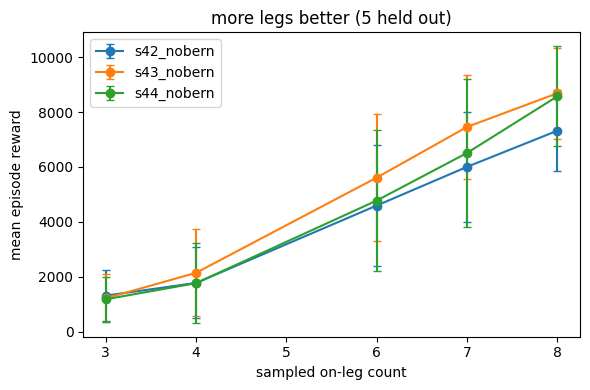

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = sorted(set(np.concatenate([d['leg_count'] for d in D.values()]).tolist()))
for s, d in D.items():
    lc, rew = d['leg_count'], d['ep_reward']
    m  = [rew[lc == k].mean() if (lc == k).any() else np.nan for k in counts]
    sd = [rew[lc == k].std()  if (lc == k).any() else np.nan for k in counts]
    ax.errorbar(counts, m, yerr=sd, marker='o', capsize=3, label=s)
ax.set_xlabel('sampled on-leg count'); ax.set_ylabel('mean episode reward')
ax.legend(); ax.set_title('more legs better (5 held out)')
plt.tight_layout(); plt.show()

## Myopia headline — `∂V/∂p` binned by `p`

**Hypothesis.** (1) *Myopia:* is `∂V/∂p` **positive at low `p`** (ascent can grow a useful-but-absent
leg) or negative (a nascent stub looks locally harmful and ascent stalls)? (2) *Shape:* the add-signal
should be **largest at low `p`** (most to gain), tapering toward `p=1` (diminishing returns).

**How it works.** Pool every (env, leg) pair across the training population, bin by `p`, plot mean
`∂V/∂p` vs `p` (faint = per seed, bold = pooled).

**What we found.** Both pass now. No myopia — `∂V/∂p` is **positive everywhere** (~99% positive in the
lowest `p` bin). And the **shape is correct**: largest at low `p` (~+10) and decaying to ~+3 by `p=1`.
This is the **inverse of the previous (poor-control) experiment**, where the curve was backwards —
weakest at low `p` (~+2.7), smallest exactly where a generator must bootstrap a leg. Fixing the control
(clean, observable bodies) fixed the signal's shape.

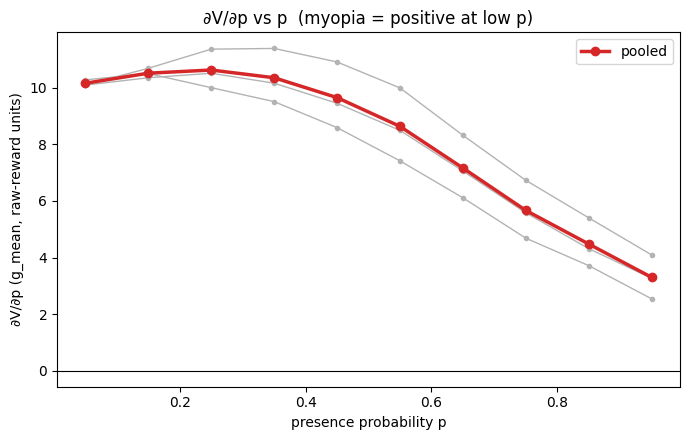

pooled frac>0 at low p (p<0.2): 0.993


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for s, p in P.items():
    ax.plot(CEN, binned(p['p'], p['gm']), color='0.7', lw=1, marker='.', zorder=1)
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ax.plot(CEN, binned(pp, gg), color='C3', lw=2.5, marker='o', label='pooled', zorder=3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean, raw-reward units)')
ax.set_title('∂V/∂p vs p  (myopia = positive at low p)'); ax.legend()
plt.tight_layout(); plt.show()
print('pooled frac>0 at low p (p<0.2):', (gg[pp < 0.2] > 0).mean().round(3))

## Marginal value — `∂V/∂p` vs `p`, split by body fullness

**Hypothesis.** Diminishing returns *across bodies*: a sparse body should value an extra leg **more**
than a full one — sparse curve above full.

**How it works.** Same binned `∂V/∂p`-vs-`p` curve, each (env, leg) pair sorted by its center's on-leg
count into **sparse** (≤3) vs **full** (≥6).

**What we found.** Both curves are positive throughout. The diminishing-returns droop is **steepest in
full bodies** (low +13.3 → high +3.0 — strong redundancy as you approach a complete body) and gentle
in sparse ones (+7.6 → +6.0). So full bodies start *higher* at low `p` and cross below sparse near
`p=1`. The pooled "largest at low p" headline is driven by the full-body curve. (Previously this split
was the *only* place any diminishing returns showed up; now it's the pooled story.)

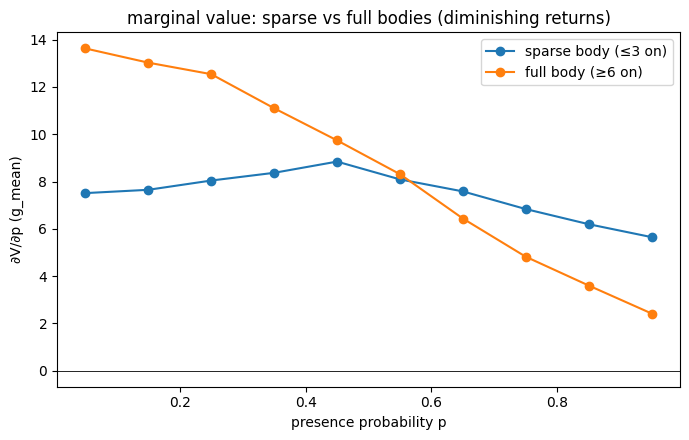

In [4]:
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ll = np.concatenate([p['lc'] for p in P.values()])
fig, ax = plt.subplots(figsize=(7, 4.5))
for mask, c, lb in [(ll <= 3, 'C0', 'sparse body (≤3 on)'), (ll >= 6, 'C1', 'full body (≥6 on)')]:
    ax.plot(CEN, binned(pp[mask], gg[mask]), marker='o', color=c, label=lb)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean)')
ax.set_title('marginal value: sparse vs full bodies (diminishing returns)'); ax.legend()
plt.tight_layout(); plt.show()

## Quorum / S-curve revisited — is there still a low-value floor?

**Hypothesis (carried over).** In the poor-control version, low-`p` legs looked low-value and we
explained it as a **quorum** effect: a barely-present leg on a barely-functional body sits on the flat
bottom of an S-shaped return-vs-legcount curve, adding little until a quorum is reached. With the good
control, is that floor still there?

**How it works.** *Left:* `∂V/∂p` vs `p` split by the body's on-leg count — within-count slope strips
out the `p`↔fullness confound. *Right:* mean `∂V/∂p` vs leg-count at a mid-`p` band (`p∈[0.4,0.6]`) —
the marginal-value "S-curve" read straight off the gradients.

**What we found — the floor is gone.** The `p`↔leg-count correlation is still mild (+0.29), but the
story flipped: within *every* fixed count the gradient is now **largest at low `p`** and declines
(3-leg +7.7→+6.3, 6-leg +14.0→+5.7) — diminishing returns, not a near-threshold climb. The leg-count
hump persists (peak ~+11 at 6 legs, drooping to +6.8 at 8) **but with a lifted floor**: even 3-leg
bodies show ~+8.5 marginal value, not the ~+1 near-zero of the poor control. So the "bottom of the
S-curve" was an artifact of a value function blind to sparse bodies — the good control values a
near-off leg highly everywhere.

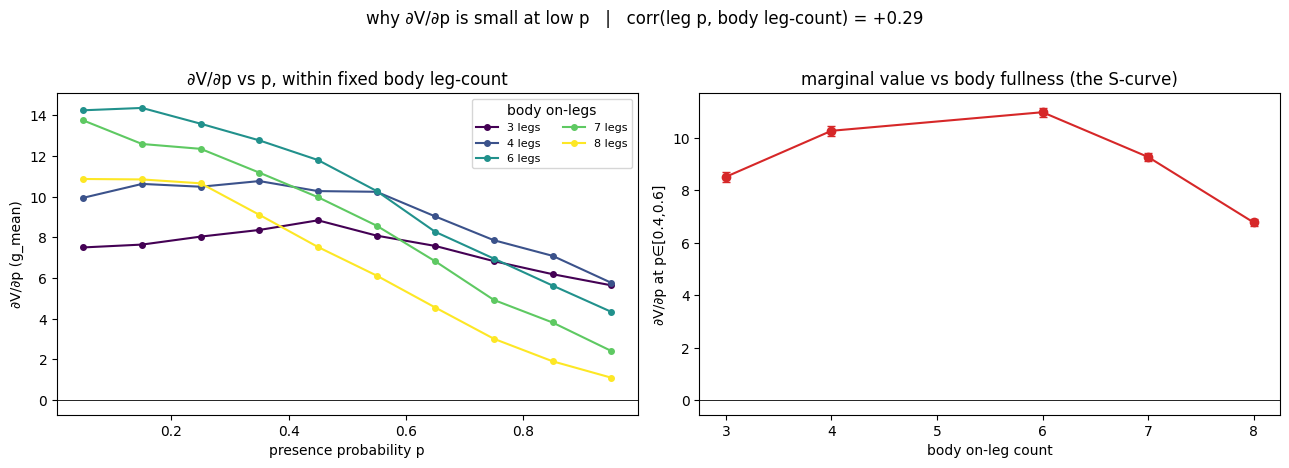

In [5]:
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
ll = np.concatenate([p['lc'] for p in P.values()])
counts = sorted(c for c in set(ll.tolist()) if (ll == c).sum() > 200)   # body leg-counts with support

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ∂V/∂p vs p WITHIN fixed body leg-count -> disambiguate fullness-confound vs real p-convexity.
cmap = plt.cm.viridis(np.linspace(0, 1, len(counts)))
for c, col in zip(counts, cmap):
    m = ll == c
    axL.plot(CEN, binned(pp[m], gg[m]), marker='o', ms=4, color=col, label=f'{int(c)} legs')
axL.axhline(0, color='k', lw=0.6)
axL.set_xlabel('presence probability p'); axL.set_ylabel('∂V/∂p (g_mean)')
axL.set_title('∂V/∂p vs p, within fixed body leg-count')
axL.legend(title='body on-legs', fontsize=8, ncol=2)

# Right: marginal value vs body leg-count at a mid-p band (strips the p↔fullness confound) -> the S-curve.
mid = (pp >= 0.4) & (pp <= 0.6)
xs = np.array(counts, float)
ys = np.array([gg[mid & (ll == c)].mean() for c in counts])
es = np.array([gg[mid & (ll == c)].std() / np.sqrt((mid & (ll == c)).sum()) for c in counts])
axR.errorbar(xs, ys, yerr=es, marker='o', capsize=3, color='C3')
axR.axhline(0, color='k', lw=0.6)
axR.set_xlabel('body on-leg count'); axR.set_ylabel('∂V/∂p at p∈[0.4,0.6]')
axR.set_title('marginal value vs body fullness (the S-curve)')

r = np.corrcoef(pp, ll)[0, 1]
fig.suptitle(f'why ∂V/∂p is small at low p   |   corr(leg p, body leg-count) = {r:+.2f}', y=1.03)
plt.tight_layout(); plt.show()

## `g0` (t=0 reset) vs `g_mean` (rollout) — static prior vs rolled-out signal

**Hypothesis.** The reset-pose gradient `g0` should roughly match the rollout-averaged `ḡ` (points on
the identity line), meaning the signal is the value net's stable *prior*, not a dynamic artifact.

**How it works.** Each point is one (env, leg): `g0` (x) vs `ḡ` (y), colored by `p`; dashed = identity.

**What we found.** They **don't** hug the line. `g0` is inflated — about **1.9× the spread** of `ḡ`
(std 10.1 vs 5.4), correlates only ~0.32, agrees on sign 93% of the time. The static reset-pose prior
is a blown-up, unreliable proxy → **trust the rollout-averaged `ḡ`**, which is what a generator sees.

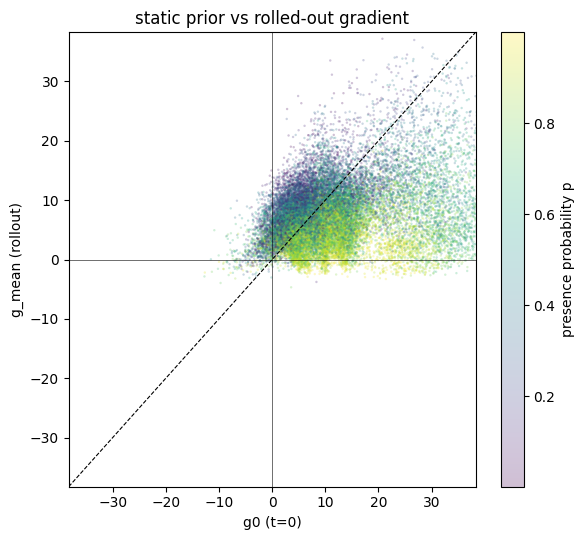

In [6]:
g0 = np.concatenate([p['g0'] for p in P.values()]); gmn = np.concatenate([p['gm'] for p in P.values()])
pv = np.concatenate([p['p'] for p in P.values()])
fig, ax = plt.subplots(figsize=(6, 5.5))
sc = ax.scatter(g0, gmn, s=3, alpha=0.25, c=pv, cmap='viridis', edgecolors='none', rasterized=True)
lim = np.percentile(np.abs(np.r_[g0, gmn]), 99)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_xlabel('g0 (t=0)'); ax.set_ylabel('g_mean (rollout)')
fig.colorbar(sc, label='presence probability p'); ax.set_title('static prior vs rolled-out gradient')
plt.tight_layout(); plt.show()

## Step 2 — curated held-out morphologies vs trained twins

**Hypothesis.** Per-leg intuition on three **held-out** bodies (redundancy {2,5,6,7}, critical {5,6,7},
symmetric {1,3,5,7}), each compared to its **trained twin** (mirror twins are task-equivalent, so they
should near-coincide). In the poor-control version the `p∈{0,1}` **corners were out-of-distribution**
and distorted the ordering, forcing us to read everything at interior `p`.

**How it works.** Bars = per-leg `∂V/∂p` seed-avg (error = seed std); held = solid, twin = hatched
(remapped so partners align). Shown at interior obs-`p` (0.75/0.25); we also rebuilt at the corners.

**What we found — two shifts.** (1) **The corners are no longer OOD.** Under the good control the off
front/right legs of *critical* are already positive at the corner (interior only sharpens them) — the
corner artifact was a symptom of the poor value function, not the probe. For the walkable pairs the
held body actually agrees with its twin *better* at the corner than interior. (2) **But per-leg twin
agreement is only moderate and noisy** (walkable pairs ~+0.6/+0.7 at corner; *critical* is a near-dead
body at reward ~25, so its match is meaningless noise). Consistent with grounding below: the gradient
is a reliable *direction*, not a reliable per-leg *ranking*.

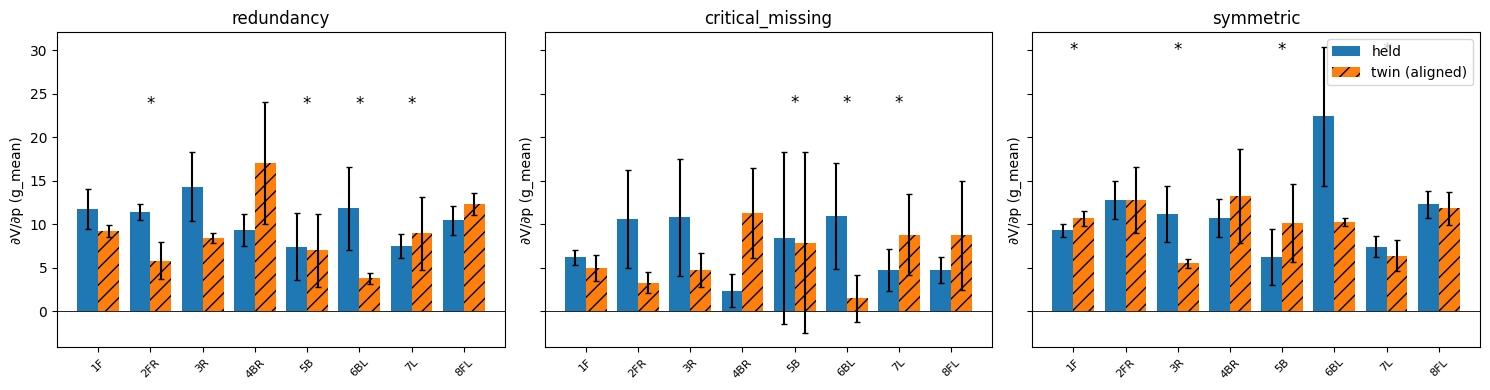

In [7]:
from matplotlib.patches import Patch
s2 = np.load(ROOT / 'data' / 'value_grad_prop' / 'step2_p0.75-0.25.npz', allow_pickle=True)
names = list(s2['names']); hm = s2['held_mask']; tmap = s2['tmap']
gh = s2['g_held']; gt = s2['g_twin']                       # (seed, set, 8)
LEG = ['1F', '2FR', '3R', '4BR', '5B', '6BL', '7L', '8FL']
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4), sharey=True)
for gi, (ax, nm) in enumerate(zip(np.atleast_1d(axes), names)):
    hmn, hsd = gh[:, gi].mean(0), gh[:, gi].std(0)
    # align twin onto held frame: held leg L partners twin leg tmap[gi,L]
    al = np.array([gt[:, gi, tmap[gi, l] - 1] for l in range(8)]).T   # (seed, 8) in held frame
    amn, asd = al.mean(0), al.std(0)
    x = np.arange(8)
    ax.bar(x - 0.2, hmn, 0.4, yerr=hsd, capsize=2, color='C0', label='held')
    ax.bar(x + 0.2, amn, 0.4, yerr=asd, capsize=2, color='C1', hatch='//', label='twin (aligned)')
    for l in range(8):                                      # mark which legs are on in the held body
        if hm[gi, l]: ax.text(l, ax.get_ylim()[1] * 0.92, '*', ha='center', fontsize=12)
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(LEG, rotation=45, fontsize=8)
    ax.set_title(nm); ax.set_ylabel('∂V/∂p (g_mean)')
np.atleast_1d(axes)[-1].legend()
plt.tight_layout(); plt.show()

## Step 3 — held-out 5-leg interpolation

**Hypothesis.** Every 5-leg body is held out, so `V` never trained on one. We expect the held-out 5-leg
`∂V/∂p`-vs-`p` curve to **coincide** with the in-distribution Step-1 curve — otherwise the signal is
garbage off the training set.

**How it works.** Use 5-leg topologies as bias centers, sweep `p` the √U way, overlay the held-out
curve (per seed) on the in-distribution Step-1 pooled curve.

**What we found.** The curves **coincide** in sign and shape — same diminishing-returns droop, the
held-out 5-leg curve sitting a touch *higher* (+12.3 low → +5.6 high vs pooled +10.2 → +3.3, as 5 legs
sit between sparse and full). The codesign signal interpolates cleanly onto a leg count `V` never
trained on.

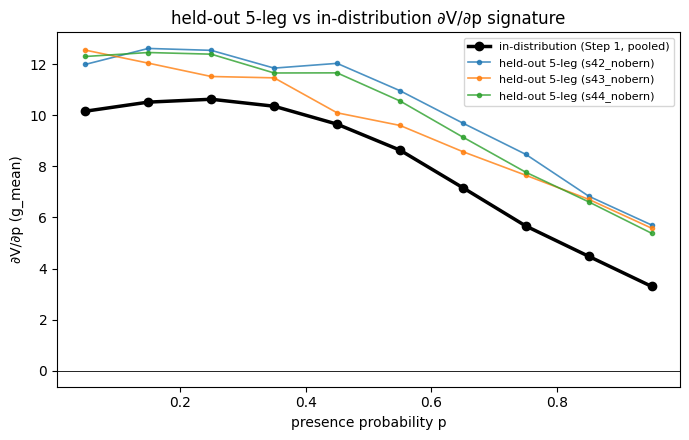

In [8]:
s3runs = sorted((ROOT / 'data' / 'value_grad_prop').glob('*/step3.npz'))
S3 = {p.parent.name: np.load(p, allow_pickle=True) for p in s3runs}
pp = np.concatenate([p['p'] for p in P.values()]); gg = np.concatenate([p['gm'] for p in P.values()])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CEN, binned(pp, gg), color='k', lw=2.5, marker='o', label='in-distribution (Step 1, pooled)', zorder=3)
for s, d in S3.items():
    ax.plot(CEN, binned(d['p'].ravel(), d['g_mean'].ravel()), marker='.', lw=1.2, alpha=0.8,
            label=f'held-out 5-leg ({s})')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('presence probability p'); ax.set_ylabel('∂V/∂p (g_mean)')
ax.set_title('held-out 5-leg vs in-distribution ∂V/∂p signature'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 3 — per-limb marginal value: 5-leg base vs ±1 leg

**Hypothesis.** From a held-out 5-leg base, **add** a random leg (→6) or **remove** a present one (→4).
Expect each remaining limb's `∂V/∂p` to **fall** when you add (diminishing returns) and **rise** when
you remove (each remaining leg more critical).

**How it works.** Three random held-out 5-leg bases (columns). Top row: base vs +1 (6-leg); bottom:
base vs −1 (4-leg). Bars seed-avg ± seed-std at interior obs-`p`; added/removed slot shaded, `*` = present.

**What we found.** The **add** side is clean — adding a leg lowers every remaining limb's gradient in
all three bases (diminishing returns ✓: 7.95→6.07, 7.47→6.10, 8.01→7.61). The **remove** side is mixed
and noisy — no clean symmetric "each leg now more critical" story, echoing the per-leg ranking noise
from Step 2.

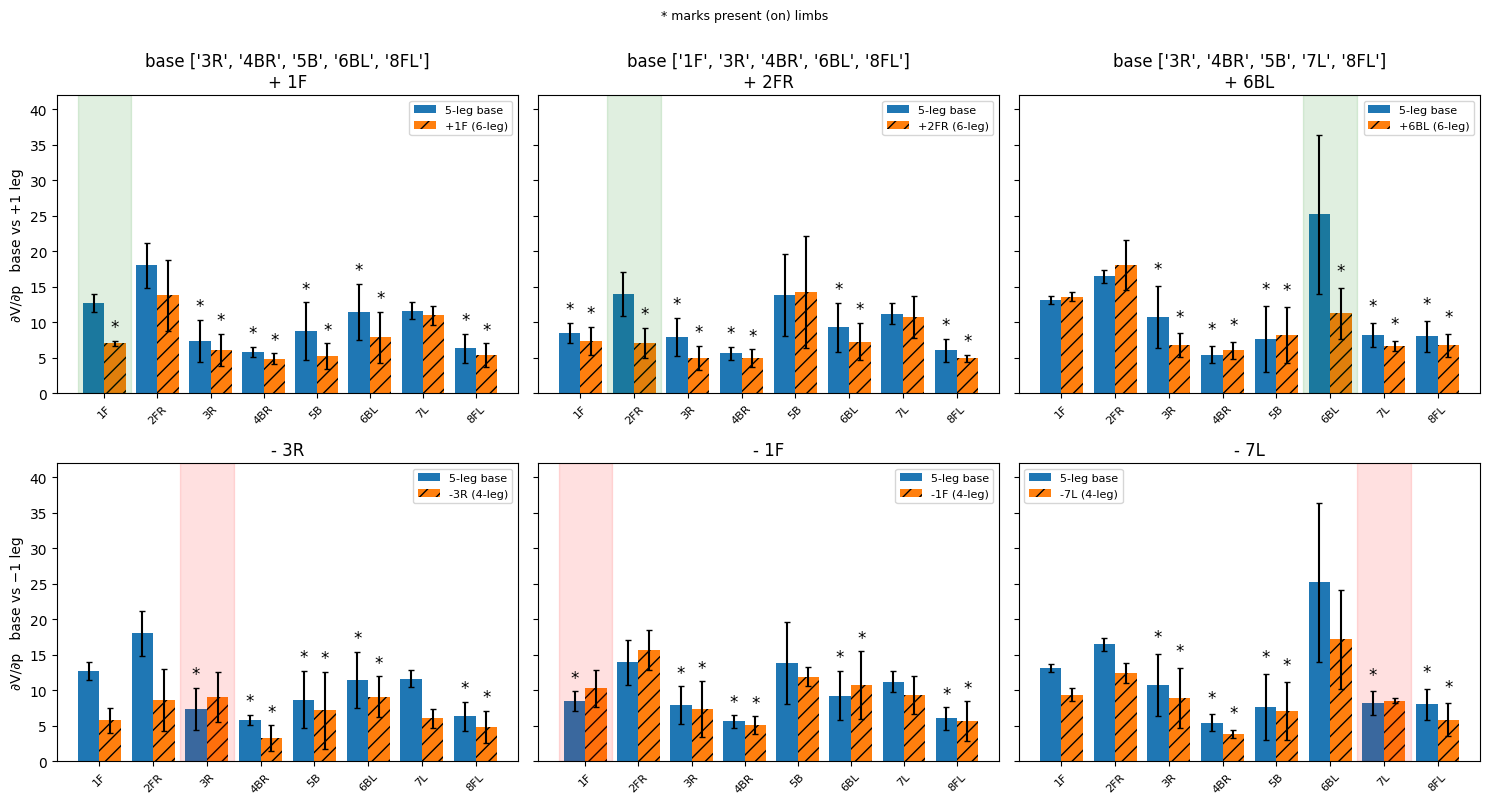

In [9]:
a3 = np.load(ROOT / 'data' / 'value_grad_prop' / 'step3_addrm.npz', allow_pickle=True)
LEG = ['1F', '2FR', '3R', '4BR', '5B', '6BL', '7L', '8FL']
gb, ga, gr = a3['g_base'], a3['g_add'], a3['g_rm']          # (seed, base, 8)
bm, am, rmsk = a3['base_mask'], a3['add_mask'], a3['rm_mask']
aleg, rleg = a3['added_leg'], a3['removed_leg']
NB_ = gb.shape[1]; x = np.arange(8); w = 0.4

def panel(ax, base, mod, mod_lbl, hl, hl_color, base_on, mod_on):
    bm_, bs = base.mean(0), base.std(0)
    mm_, ms = mod.mean(0), mod.std(0)
    ax.bar(x - w/2, bm_, w, yerr=bs, capsize=2, color='C0', label='5-leg base')
    ax.bar(x + w/2, mm_, w, yerr=ms, capsize=2, color='C1', hatch='//', label=mod_lbl)
    ax.axvspan(hl - 0.5, hl + 0.5, color=hl_color, alpha=0.12)   # the added/removed slot
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(LEG, rotation=45, fontsize=8)
    pad = 0.03 * max(1.0, float((bm_ + bs).max()), float((mm_ + ms).max()))
    for l in range(8):                                          # star above each ON bar
        if base_on[l]: ax.text(l - w/2, max(bm_[l] + bs[l], 0) + pad, '*', ha='center', va='bottom', fontsize=12)
        if mod_on[l]:  ax.text(l + w/2, max(mm_[l] + ms[l], 0) + pad, '*', ha='center', va='bottom', fontsize=12)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, NB_, figsize=(5 * NB_, 8), sharey='row')
for i in range(NB_):
    base_legs = [LEG[l] for l in range(8) if bm[i, l]]
    panel(axes[0, i], gb[:, i], ga[:, i], f'+{LEG[aleg[i]-1]} (6-leg)', aleg[i] - 1, 'green', bm[i], am[i])
    axes[0, i].set_title(f'base {base_legs}\n+ {LEG[aleg[i]-1]}')
    panel(axes[1, i], gb[:, i], gr[:, i], f'-{LEG[rleg[i]-1]} (4-leg)', rleg[i] - 1, 'red', bm[i], rmsk[i])
    axes[1, i].set_title(f'- {LEG[rleg[i]-1]}')
for r in range(2):                                             # headroom so stars don't clip (sharey=row)
    lo, hi = axes[r, 0].get_ylim(); axes[r, 0].set_ylim(lo, hi + 0.10 * (hi - lo))
axes[0, 0].set_ylabel('∂V/∂p   base vs +1 leg'); axes[1, 0].set_ylabel('∂V/∂p   base vs −1 leg')
fig.suptitle('* marks present (on) limbs', y=1.0, fontsize=9)
plt.tight_layout(); plt.show()

## Grounding — does realized return back up V and its gradient?

**Hypothesis.** Steps 1–3 judged `∂V/∂p` against *intuition*; here we ground it against *realized
return*. If the signal is trustworthy: (1) `V` tracks realized return `R` across bodies, and (2)
`∂V/∂p_L` predicts the **realized** marginal value of leg `L`, `ΔR_L = R(with L) − R(without L)`.

**How it works.** 16 in-distribution base bodies (4 each at 3/4/6/7 legs), each built deterministically
at interior obs-`p` (0.75/0.25) with its 8 single-leg **toggles**. Measure realized `R`, value `V` (at
reset), and per-leg `∂V/∂p`. Seed-avg over s42/43/44. *Left:* `V` vs `R`. *Right:* `∂V/∂p_L` vs `ΔR_L`,
colored by base leg-count.

**What we found.**
- **Value tracks return well in rank** — Pearson +0.89, Spearman +0.87; the critic orders bodies
  good→bad correctly. (Absolute `V` is compressed — ~[105,136] vs realized 1252–6675 — it predicts
  *discounted* return-to-go; calibration is rank, not scale.)
- **The gradient nails the sign (1.00)** — though partly trivial here, since nearly every leg has
  positive realized value (more legs better).
- **Magnitude still doesn't predict which leg helps** — overall Pearson −0.08, and the by-fullness cut
  **inverts** relative to the poor control: weakly positive in **sparse** bodies now (3-leg +0.35),
  ~0/negative in functional ones (6-leg −0.20, 7-leg +0.03), where before it was the other way around.
  Add-side is the only consistent winner (r=+0.45); removing is not (ρ=−0.17).

**Takeaway.** Sign/direction is reliable; magnitude is not a dependable "which leg" signal under either
control. The next cell shows *why* — and why the reason differs from the poor-control version.

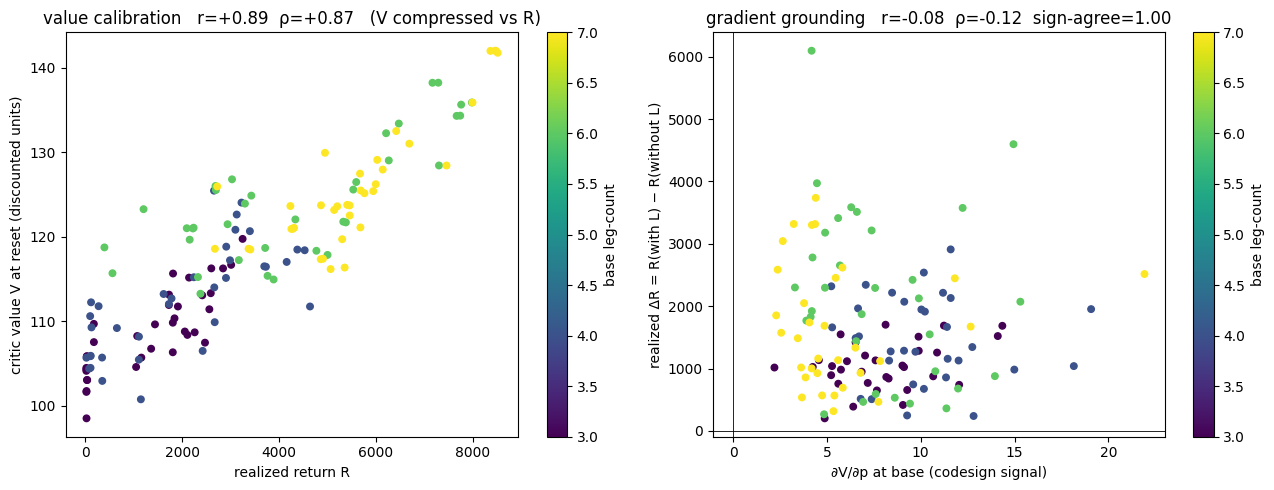

value calibration:  pearson +0.886  spearman +0.872
gradient grounding: pearson -0.079  spearman -0.116  sign-agree 1.000
  add (leg off): r=+0.452   remove (leg on): ρ=-0.171
  3-leg bases: pearson +0.346  (n=32)
  4-leg bases: pearson -0.085  (n=32)
  6-leg bases: pearson -0.196  (n=32)
  7-leg bases: pearson +0.033  (n=32)


In [10]:
from scipy.stats import spearmanr
abl = np.load(ROOT / 'data' / 'value_grad_prop' / 'ablation.npz', allow_pickle=True)
V, R, gB = abl['V'], abl['R'], abl['g_base']          # (seed,base,9) V & R ; (seed,base,8) base ∂V/∂p
bm, lc = abl['base_mask'], abl['leg_count']
Vm, Rm, Gm = V.mean(0), R.mean(0), gB.mean(0)         # seed-avg

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# Left: value calibration — does the critic's V track realized return R, over all bodies?
lcb = np.repeat(lc[:, None], V.shape[2], 1).ravel()   # base leg-count tag per body
rr, vv = Rm.ravel(), Vm.ravel()
sc = axL.scatter(rr, vv, c=lcb, cmap='viridis', s=22)
plt.colorbar(sc, ax=axL, label='base leg-count')
axL.set_xlabel('realized return R'); axL.set_ylabel('critic value V at reset (discounted units)')
axL.set_title(f'value calibration   r={np.corrcoef(rr, vv)[0,1]:+.2f}  '
              f'ρ={spearmanr(rr, vv).statistic:+.2f}   (V compressed vs R)')

# Right: gradient grounding — does ∂V/∂p_L predict the realized marginal value of leg L?
sign = np.where(bm == 1, 1.0, -1.0)                   # +1 if leg on in base else -1
dR = sign * (Rm[:, [0]] - Rm[:, 1:])                  # (base,8): R(with L) − R(without L)
x, y = Gm.ravel(), dR.ravel()
lcg = np.repeat(lc[:, None], 8, 1).ravel()            # base leg-count per (base,leg) point
sc2 = axR.scatter(x, y, c=lcg, cmap='viridis', s=22)
plt.colorbar(sc2, ax=axR, label='base leg-count')
axR.axhline(0, color='k', lw=0.6); axR.axvline(0, color='k', lw=0.6)
axR.set_xlabel('∂V/∂p at base (codesign signal)'); axR.set_ylabel('realized ΔR = R(with L) − R(without L)')
axR.set_title(f'gradient grounding   r={np.corrcoef(x, y)[0,1]:+.2f}  ρ={spearmanr(x, y).statistic:+.2f}  '
              f'sign-agree={(np.sign(x) == np.sign(y)).mean():.2f}')
plt.tight_layout(); plt.show()

print(f'value calibration:  pearson {np.corrcoef(rr, vv)[0,1]:+.3f}  spearman {spearmanr(rr, vv).statistic:+.3f}')
print(f'gradient grounding: pearson {np.corrcoef(x, y)[0,1]:+.3f}  spearman {spearmanr(x, y).statistic:+.3f}  '
      f'sign-agree {(np.sign(x) == np.sign(y)).mean():.3f}')
on = (bm == 1).ravel()
print(f'  add (leg off): r={np.corrcoef(x[~on], y[~on])[0,1]:+.3f}   remove (leg on): ρ={spearmanr(x[on], y[on]).statistic:+.3f}')
for c in sorted(set(lc.tolist())):
    m = lcg == c
    print(f'  {c}-leg bases: pearson {np.corrcoef(x[m], y[m])[0,1]:+.3f}  (n={m.sum()})')

## Why magnitude still fails — but differently than the poor control

**Hypothesis.** In the poor-control version the magnitude failed because the value function was **blind
at the floor**: its own finite-difference `ΔV = V(with leg) − V(without leg)` failed *together* with
the gradient in sparse bodies — `V` never learned which leg mattered, so no derivative could recover
it. Does the same hold under the good control?

**How it works.** Reuse the ablation data. *Left:* per leg-count, correlate realized `ΔR` with **two**
predictors — the analytic gradient `∂V/∂p` AND the critic's own finite-difference `ΔV` (which actually
crosses the toggle). If `V` is blind, both fail together (the poor-control result); if `V` knows but
the gradient can't read it, `ΔV` beats the gradient. *Right:* `V`'s output range per leg-count vs
realized return.

**What we found — the diagnosis flipped.** Under the good control `V` is **not** blind:
- On **functional bodies (6–7 legs) the critic's `ΔV` is clearly positive** (+0.20, +0.42) — `V` *does*
  now encode which leg matters — **yet the analytic gradient diverges from it** (−0.20, +0.03). On
  sparse bodies (3-leg) both are positive (+0.35/+0.47). So it's no longer "the value function never
  learned it"; it's "the value function knows, but the **local slope in `p` doesn't point the same way
  as a discrete leg toggle**."
- `V` is still **rank-compressed** ([105,136] for realized 1252–6675), so magnitudes are squashed.

**Why.** With `p` now an obs/value-only signal and the body held fixed at the center, `∂V/∂p` measures
sensitivity to the *reported presence*, while a real leg toggle (`ΔV`) changes the *body*. On a
functional body those decouple — gradient and finite-difference disagree. Practical upshot: **use the
gradient for sign/direction, but use the critic's finite-difference `ΔV` (or realized-return ablation)
for magnitude** on bodies that already walk. (Contrast the poor control, where `ΔV` offered no rescue
because `V` itself was wrong.)

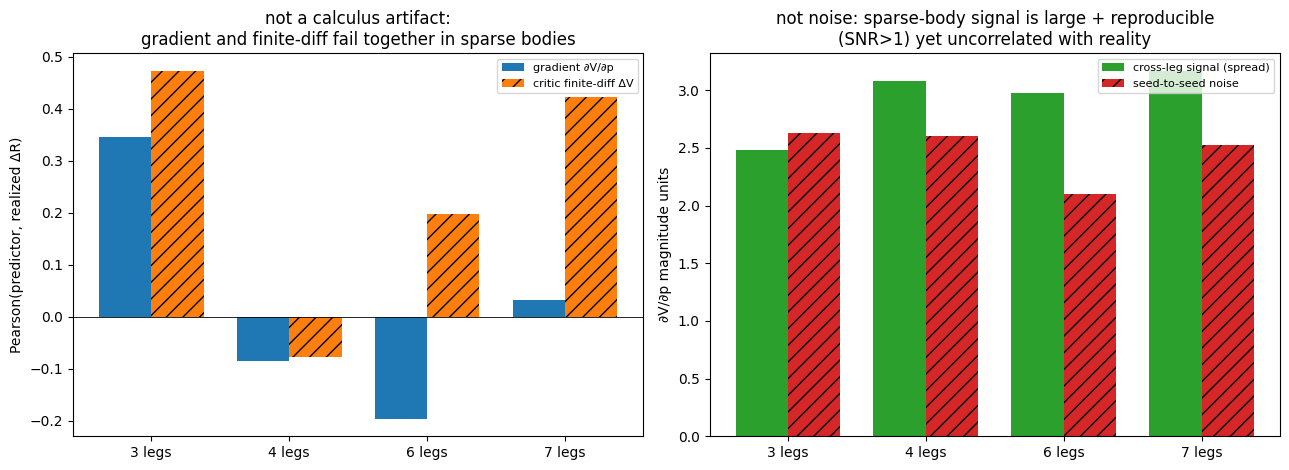

corr(∂V/∂p, ΔR) vs corr(ΔV, ΔR) by leg-count:
  3-leg: gradient +0.35   finite-diff +0.47
  4-leg: gradient -0.08   finite-diff -0.08
  6-leg: gradient -0.20   finite-diff +0.20
  7-leg: gradient +0.03   finite-diff +0.42
V allocates almost no output range to low-return bodies:
  3-leg: V_base in [105,112]   (realized R_base mean 1252)
  4-leg: V_base in [107,115]   (realized R_base mean 2016)
  6-leg: V_base in [126,132]   (realized R_base mean 5447)
  7-leg: V_base in [126,136]   (realized R_base mean 6675)


In [11]:
from scipy.stats import spearmanr
abl = np.load(ROOT / 'data' / 'value_grad_prop' / 'ablation.npz', allow_pickle=True)
V, R, gB = abl['V'], abl['R'], abl['g_base']
bm, lc = abl['base_mask'], abl['leg_count']
Vm, Rm, Gm = V.mean(0), R.mean(0), gB.mean(0)
sign = np.where(bm == 1, 1.0, -1.0)
dR = sign * (Rm[:, [0]] - Rm[:, 1:])            # realized marginal value of leg L     (base,8)
dV = sign * (Vm[:, [0]] - Vm[:, 1:])            # critic finite-diff predicted leg value (base,8)
counts = sorted(set(lc.tolist())); xpos = np.arange(len(counts)); w = 0.38

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: corr(predictor, realized ΔR) by leg-count — gradient vs the critic's OWN finite-difference.
def corr_by(arr):
    return [np.corrcoef(arr[lc == c].ravel(), dR[lc == c].ravel())[0, 1] for c in counts]
axL.bar(xpos - w/2, corr_by(Gm), w, color='C0', label='gradient ∂V/∂p')
axL.bar(xpos + w/2, corr_by(dV), w, color='C1', hatch='//', label='critic finite-diff ΔV')
axL.axhline(0, color='k', lw=0.6); axL.set_xticks(xpos); axL.set_xticklabels([f'{c} legs' for c in counts])
axL.set_ylabel('Pearson(predictor, realized ΔR)')
axL.set_title('not a calculus artifact:\ngradient and finite-diff fail together in sparse bodies')
axL.legend(fontsize=8)

# Right: is the sparse-body magnitude just noise? cross-leg signal vs seed-to-seed noise.
spread = [Gm[lc == c].std(1).mean() for c in counts]   # spread across legs within a body = the signal
noise  = [gB.std(0)[lc == c].mean() for c in counts]   # seed-to-seed std of a single leg's gradient
axR.bar(xpos - w/2, spread, w, color='C2', label='cross-leg signal (spread)')
axR.bar(xpos + w/2, noise,  w, color='C3', hatch='//', label='seed-to-seed noise')
axR.set_xticks(xpos); axR.set_xticklabels([f'{c} legs' for c in counts])
axR.set_ylabel('∂V/∂p magnitude units')
axR.set_title('not noise: sparse-body signal is large + reproducible\n(SNR>1) yet uncorrelated with reality')
axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('corr(∂V/∂p, ΔR) vs corr(ΔV, ΔR) by leg-count:')
for c, g_, v_ in zip(counts, corr_by(Gm), corr_by(dV)):
    print(f'  {c}-leg: gradient {g_:+.2f}   finite-diff {v_:+.2f}')
print('V allocates almost no output range to low-return bodies:')
for c in counts:
    m = lc == c
    print(f'  {c}-leg: V_base in [{Vm[m,0].min():.0f},{Vm[m,0].max():.0f}]   (realized R_base mean {Rm[m,0].mean():.0f})')

## Phase 2 — gradient through a continuous-`p` generator (conditioning check)

**Hypothesis.** Does the *sign* survive being routed through a generator network? The earlier **binary**
version failed here — its discrete generator's sigmoid saturated and the gradient collapsed ~3 orders.
The continuous-`p` recast should keep the sigmoid unsaturated and preserve the sign ascent consumes.

**How it works.** A small transformer (the generator analogue) is pretrained (MSE) to regress each
leg's `p` from a *scattered-`p`* puzzle — it must attend across tokens to gather each value — then
frozen and composed in front of the frozen value net. We compare the **composed** input-gradient to the
**direct** `∂V/∂p`. *Left:* per-(leg, env) scatter, direct (x) vs composed (y); *right:* backward
grad-norm chain from generator output back to input (should not collapse).

**What we found.** The sign **survives** — sign-alignment **0.95**, the norm chain doesn't vanish
(998 → 248 → 2641 → 1622, ending above where it starts). Magnitude is only moderately preserved
(corr ~0.59), but sign is what ascent needs. The continuous recast fixes the binary version's collapse
by construction, and the good control doesn't change that.

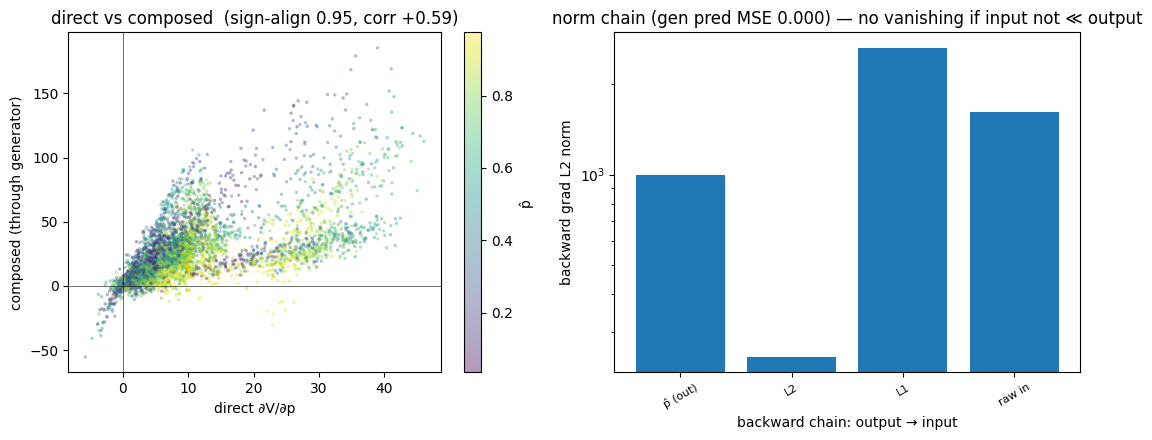

In [12]:
p2 = np.load(ROOT / 'data' / 'value_grad_prop' / 'phase2.npz', allow_pickle=True)
d = p2['direct'].ravel(); cm = p2['composed'].ravel(); ph = p2['phat'].ravel()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax[0].scatter(d, cm, s=6, alpha=0.4, c=ph, cmap='viridis', edgecolors='none')
ax[0].axhline(0, color='k', lw=0.4); ax[0].axvline(0, color='k', lw=0.4)
ax[0].set_xlabel('direct ∂V/∂p'); ax[0].set_ylabel('composed (through generator)')
ax[0].set_title(f'direct vs composed  (sign-align {float(p2["sign_match"]):.2f}, '
                f'corr {float(p2["corr"]):+.2f})')
fig.colorbar(sc, ax=ax[0], label='p̂')
ch = p2['chain_norms']
labels = ['p̂ (out)'] + [f'L{len(ch)-2-i}' for i in range(len(ch) - 2)] + ['raw in']
ax[1].bar(range(len(ch)), ch); ax[1].set_yscale('log')
ax[1].set_xticks(range(len(ch))); ax[1].set_xticklabels(labels, rotation=30, fontsize=8)
ax[1].set_xlabel('backward chain: output → input'); ax[1].set_ylabel('backward grad L2 norm')
ax[1].set_title(f'norm chain (gen pred MSE {float(p2["pred_mse"]):.3f}) — no vanishing if input not ≪ output')
plt.tight_layout(); plt.show()